In [1]:
%pip install -U transformers accelerate datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12

In [2]:
import json
import os
from datasets import Dataset

# --- 1) Đường dẫn file JSON và root folder ---
json_file = "/kaggle/input/lungcancerllm/LLM_Lung_Project/train/train.json"
root = "/kaggle/input/lungcancerllm/LLM_Lung_Project/train/images"

# --- 2) Đọc file JSON ---
with open(json_file, "r", encoding="utf-8") as f:
    json_data = json.load(f)

print(f"Tổng số mẫu trong JSON: {len(json_data)}")

# --- 3) Chuẩn hóa dữ liệu ---
data = []
for item in json_data:
    img_path = item["image"].replace("\\", "/")
    img_name = os.path.basename(img_path)
    full_path = os.path.join(root, img_name)
    data.append({
        "image": full_path,
        "text": item["text"]
    })

print(f"Tổng số mẫu sau xử lý: {len(data)}")
print(data[0])


Tổng số mẫu trong JSON: 9031
Tổng số mẫu sau xử lý: 9031
{'image': '/kaggle/input/lungcancerllm/LLM_Lung_Project/train/images/PMC2646742_1752-1947-3-46-2.jpg', 'text': 'Computed tomography scan of the liver showing the liver abscess.'}


In [3]:
from datasets import Dataset

dataset = Dataset.from_list(data)

Let's check whether the dataset is created correctly:

In [4]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 9031
})

Let's take a look at one example:

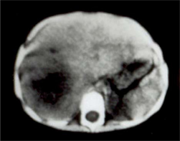

Computed tomography scan of the liver showing the liver abscess.


In [5]:
from PIL import Image
from IPython.display import display

example = dataset[0]

# Đọc đường dẫn ảnh
img_path = example["image"]
image = Image.open(img_path).convert("RGB")

width, height = image.size

# Hiển thị ảnh thu nhỏ 30%
display(image.resize((int(0.3*width), int(0.3*height))))

# Hiển thị text
print(example["text"])

Let's check its corresponding caption:

## Create PyTorch Dataset

In [6]:
from torch.utils.data import Dataset

class ImageCaptioningDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        image = Image.open(item["image"]).convert("RGB")

        encoding = self.processor(
            images=image,
            text=item["text"],
            # padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # remove batch dimension
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}

        # Đảm bảo pixel_values có kích thước [C, H, W]
        if encoding['pixel_values'].dim() == 4:
            encoding['pixel_values'] = encoding['pixel_values'].squeeze(0)

        if encoding.get('input_ids') is not None:
             encoding["labels"] = encoding["input_ids"].clone()

        return encoding

In [7]:
from transformers import AutoProcessor

# processor = AutoProcessor.from_pretrained("microsoft/git-base")
processor = AutoProcessor.from_pretrained("microsoft/git-large-textcaps")

2025-12-01 02:38:47.180888: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764556727.413869      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764556727.478068      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [8]:
train_dataset = ImageCaptioningDataset(dataset, processor)

Let's check one example of the dataset:

In [9]:
item = train_dataset[0]
for k,v in item.items():
  print(k,v.shape)

pixel_values torch.Size([3, 224, 224])
input_ids torch.Size([16])
attention_mask torch.Size([16])
labels torch.Size([16])


## Create PyTorch DataLoader

In [10]:
from torch.utils.data import DataLoader
from transformers import DataCollatorForSeq2Seq

# Data collator cho dynamic padding
collator = DataCollatorForSeq2Seq(
    tokenizer=processor.tokenizer,
    padding=True,          # padding batch động
    return_tensors="pt"
)

# Dataloader
train_dataloader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collator    # quan trọng
)

In [11]:
batch = next(iter(train_dataloader))
for k,v in batch.items():
  print(k,v.shape)

pixel_values torch.Size([2, 3, 224, 224])
input_ids torch.Size([2, 47])
attention_mask torch.Size([2, 47])
labels torch.Size([2, 47])


/usr/local/lib/python3.11/dist-packages/transformers/data/data_collator.py:740: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Let's check one batch, and do some sanity checks. We can decode the input_ids back into text for instance:

In [12]:
processor.decode(batch["input_ids"][0])

'[CLS] multiple lung metastases on a 72yo patient treated for cervix tumor [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

We can "denormalize" the pixel values to get back an image:

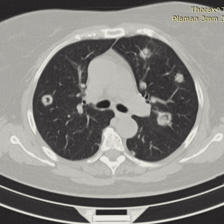

In [13]:
from PIL import Image
import numpy as np

MEAN = np.array([123.675, 116.280, 103.530]) / 255
STD = np.array([58.395, 57.120, 57.375]) / 255

unnormalized_image = (batch["pixel_values"][0].numpy() * np.array(STD)[:, None, None]) + np.array(MEAN)[:, None, None]
unnormalized_image = (unnormalized_image * 255).astype(np.uint8)
unnormalized_image = np.moveaxis(unnormalized_image, 0, -1)
Image.fromarray(unnormalized_image)

## Define model

Next, we instantiate a model. We start from the pre-trained GIT-base model (which was already pre-trained on 4 million image-text pairs by Microsoft).

In [14]:
from transformers import AutoModelForCausalLM

# model = AutoModelForCausalLM.from_pretrained("microsoft/git-base")
model = AutoModelForCausalLM.from_pretrained("microsoft/git-large-textcaps")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

## Dummy forward pass

In [15]:
outputs = model(input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                pixel_values=batch["pixel_values"],
                labels=batch["input_ids"])
outputs.loss

tensor(9.7169, grad_fn=<NllLossBackward0>)

## Train the model

In [16]:
import torch
from tqdm import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.train()

EPOCHS = 5

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")
    epoch_loss = 0

    for batch in tqdm(train_dataloader):

        input_ids = batch["input_ids"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            labels=input_ids
        )

        loss = outputs.loss
        epoch_loss += loss.item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f">>> Average Loss: {epoch_loss / len(train_dataloader):.4f}")

# ===== Lưu model =====
save_path = "/kaggle/working/git_finetuned"
model.save_pretrained(save_path)
processor.save_pretrained(save_path)
print(f"✅ Model đã được lưu tại: {save_path}")


===== Epoch 1/5 =====


100%|██████████| 4516/4516 [23:14<00:00,  3.24it/s]


>>> Average Loss: 3.9238

===== Epoch 2/5 =====


100%|██████████| 4516/4516 [23:14<00:00,  3.24it/s]


>>> Average Loss: 3.3389

===== Epoch 3/5 =====


...

>>> Average Loss: 2.9756

===== Epoch 4/5 =====


100%|██████████| 4516/4516 [23:15<00:00,  3.24it/s]


>>> Average Loss: 2.6533

===== Epoch 5/5 =====


100%|██████████| 4516/4516 [23:15<00:00,  3.24it/s]


>>> Average Loss: 2.3372
✅ Model đã được lưu tại: /kaggle/working/git_finetuned


## Inference

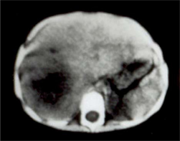

Computed tomography scan of the liver showing the liver abscess.


In [17]:
from PIL import Image
from IPython.display import display

example = dataset[0]

# Đọc đường dẫn ảnh
img_path = example["image"]
image = Image.open(img_path).convert("RGB")

width, height = image.size

# Hiển thị ảnh thu nhỏ 30%
display(image.resize((int(0.3*width), int(0.3*height))))

# Hiển thị text
print(example["text"])

In [18]:
# %pip install sentencepiece

In [19]:
# from transformers import MarianTokenizer, MarianMTModel

# model_name = "Helsinki-NLP/opus-mt-en-vi"
# trans_tokenizer = MarianTokenizer.from_pretrained(model_name)
# trans_model = MarianMTModel.from_pretrained(model_name).to(device)

In [20]:
# Generate caption
inputs = processor(images=image, return_tensors="pt").to(device)

generated_ids = model.generate(
    pixel_values=inputs["pixel_values"],
    max_length=256,
    num_beams=5,
    no_repeat_ngram_size=2,
    repetition_penalty=1.2,
    early_stopping=True
)

generated_caption = processor.decode(generated_ids[0], skip_special_tokens=True)
print("Caption (English):", generated_caption)

# batch = trans_tokenizer([generated_caption], return_tensors="pt").to(device)
# translated = trans_model.generate(**batch, max_length=256)

# translated_caption = trans_tokenizer.decode(translated[0], skip_special_tokens=True)
# print("Caption (Vietnamese):", translated_caption)

Caption (English): computedography of chest right sidedeur eusion


# Evaluate

In [21]:
import json
import os
from datasets import Dataset

# --- 1) Đường dẫn file JSON và root folder ---
json_file = "/kaggle/input/lungcancerllm/LLM_Lung_Project/test/test.json"
root = "/kaggle/input/lungcancerllm/LLM_Lung_Project/test/images"

# --- 2) Đọc file JSON ---
with open(json_file, "r", encoding="utf-8") as f:
    json_data = json.load(f)

print(f"Tổng số mẫu trong JSON: {len(json_data)}")

# --- 3) Chuẩn hóa dữ liệu ---
data = []
for item in json_data:
    img_path = item["image"].replace("\\", "/")
    img_name = os.path.basename(img_path)
    full_path = os.path.join(root, img_name)
    data.append({
        "image": full_path,
        "text": item["text"]
    })

print(f"Tổng số mẫu sau xử lý: {len(data)}")

test_dataset = Dataset.from_list(data)
test_dataset

Tổng số mẫu trong JSON: 1004
Tổng số mẫu sau xử lý: 1004


Dataset({
    features: ['image', 'text'],
    num_rows: 1004
})

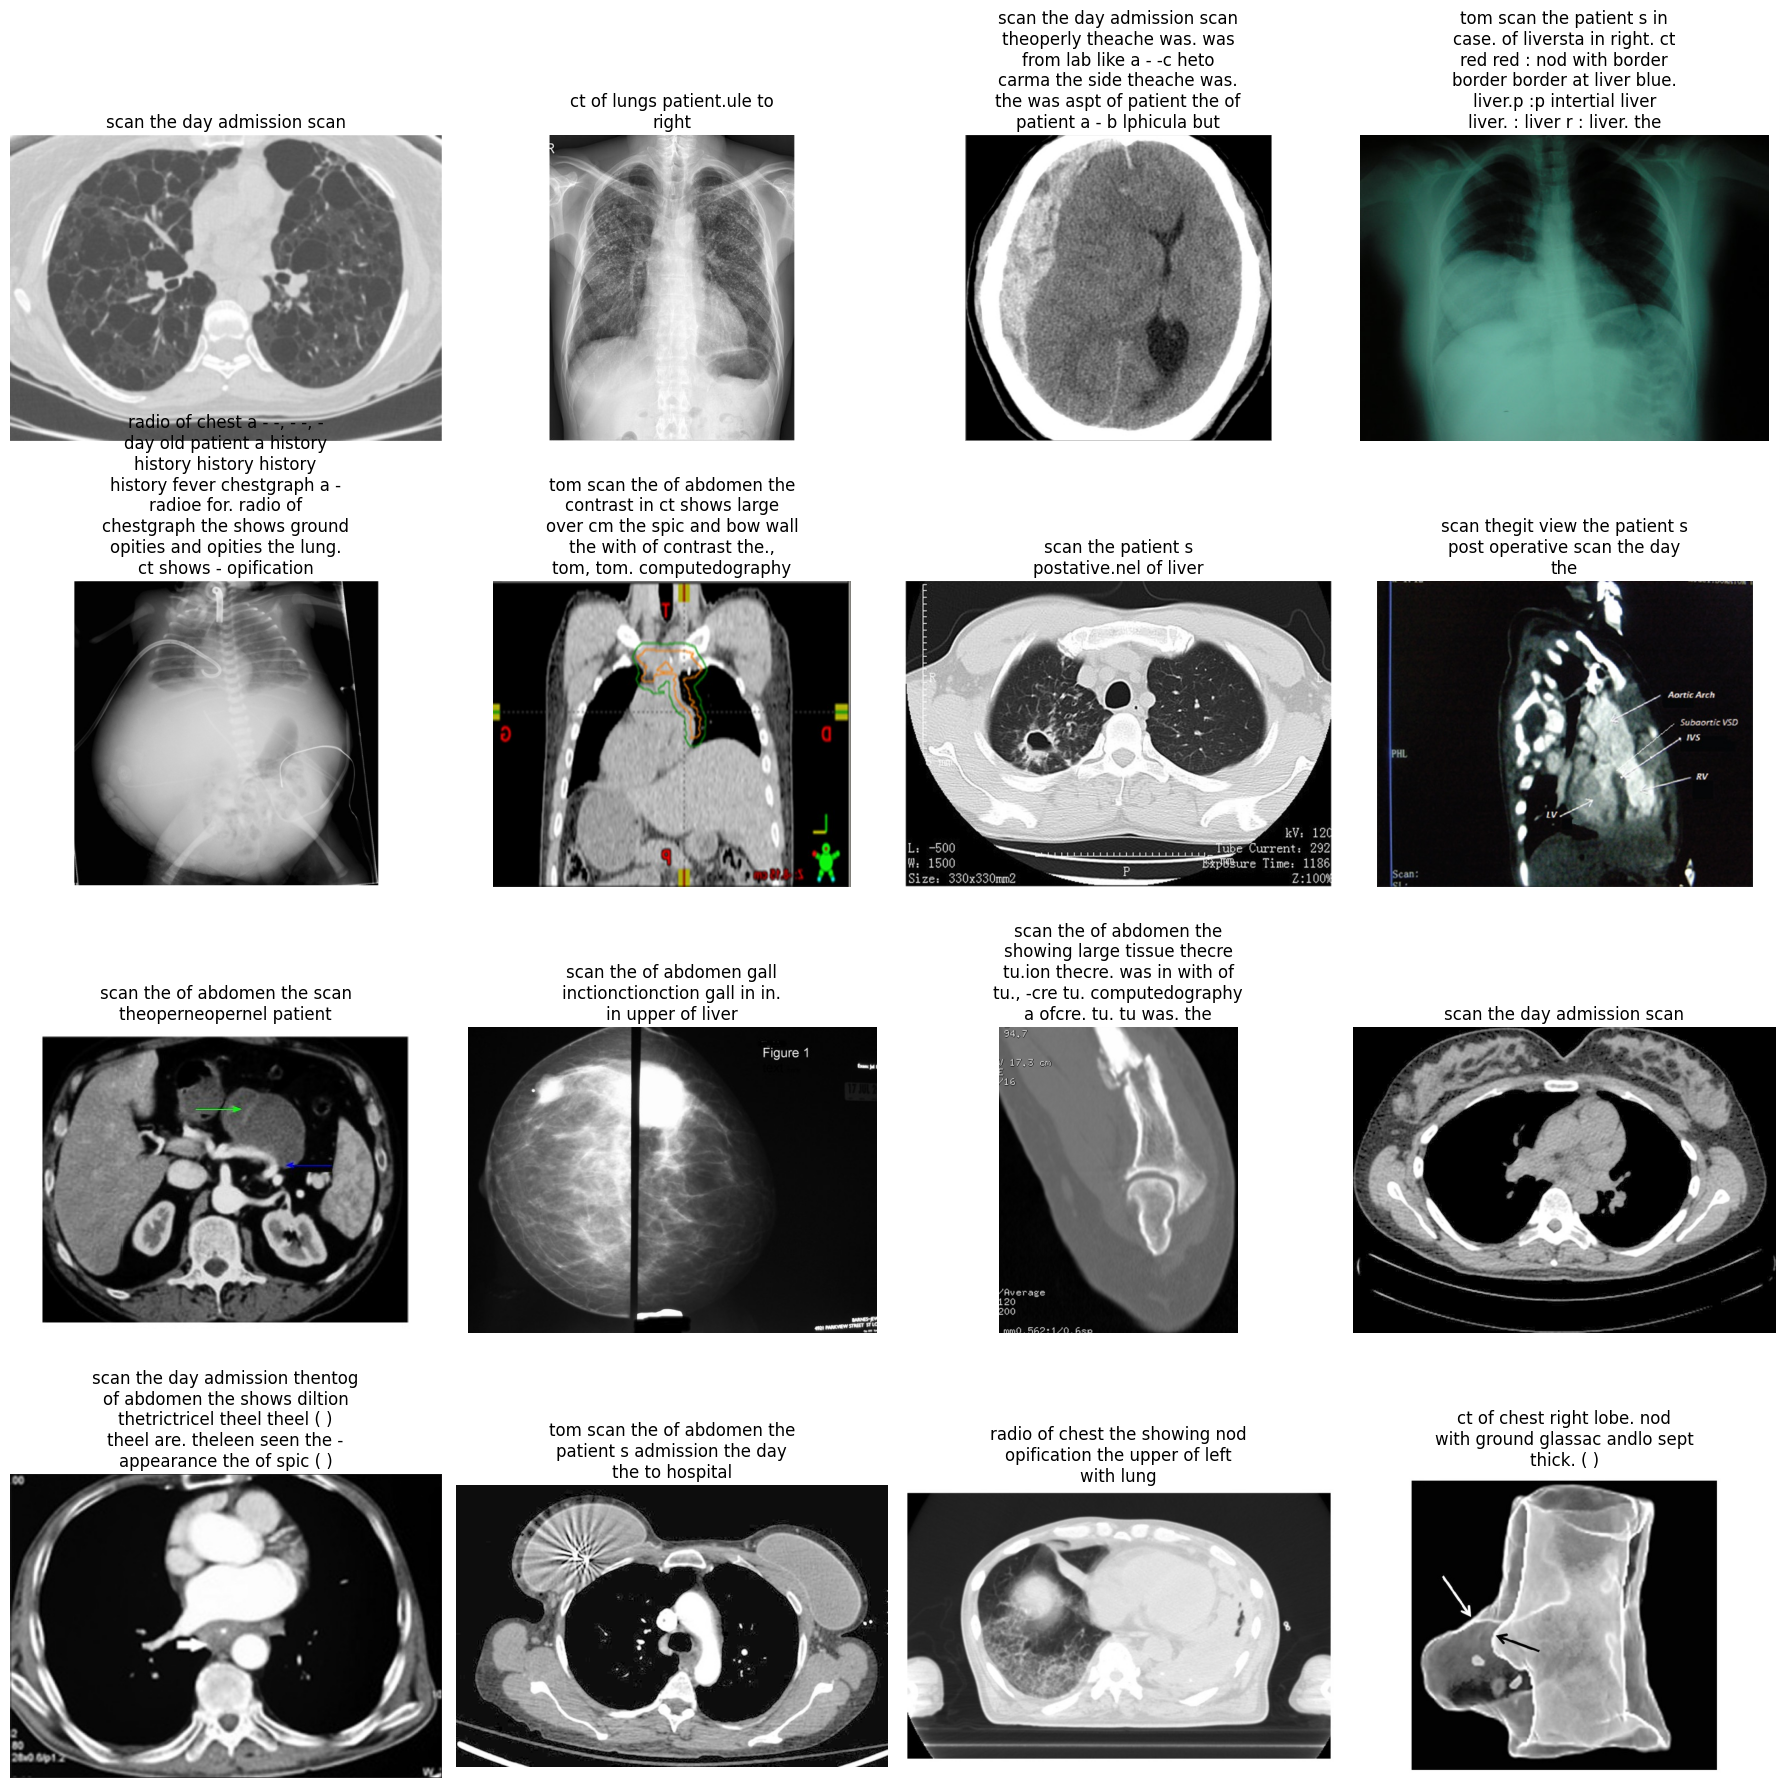

In [22]:
import textwrap
from PIL import Image
import matplotlib.pyplot as plt

# Predict 16 images of Test Data from trained model
fig = plt.figure(figsize=(18, 18))

for i, example in enumerate(test_dataset):
    img_path = example["image"]                         # path của ảnh
    image = Image.open(img_path).convert("RGB")         # load ảnh

    inputs = processor(images=image, return_tensors="pt").to(device)
    pixel_values = inputs.pixel_values

    generated_ids = model.generate(pixel_values=pixel_values, max_length=50)
    generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    wrapped_caption = textwrap.fill(generated_caption, width=30)

    fig.add_subplot(4, 4, i+1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(wrapped_caption)

    if i == 15:
        break

plt.tight_layout()
plt.show()

In [23]:
%pip install evaluate nltk pillow sacrebleu rouge_score

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 9.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [24]:
print("\nBắt đầu đánh giá định lượng trên toàn bộ tập test...")

import evaluate
import nltk
from tqdm import tqdm
from PIL import Image

# 1. Load metrics
bleu_metric = evaluate.load("sacrebleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")

# 2. Cần thiết cho ROUGE và METEOR
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

all_predictions = []
all_references = []

# 3. Evaluate on test set
model.eval()

for item in tqdm(test_dataset, desc="Evaluating all test samples"):
    reference_text = item["text"]      # giữ nguyên
    img_path = item.get("image")

    try:
        image = Image.open(img_path).convert("RGB")  # mở ảnh

        # Chuẩn bị input và sinh văn bản dự đoán
        inputs = processor(images=image, return_tensors="pt").to(device)
        generated_ids = model.generate(**inputs, max_new_tokens=128)
        gen_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

        # Lưu kết quả
        all_predictions.append(gen_text)
        all_references.append(reference_text)

    except Exception as e:
        print("Error:", e)
        all_predictions.append("")
        all_references.append(reference_text)

# 4. Compute scores
print("\nĐang tính toán điểm số...")

try:
    bleu_score = bleu_metric.compute(
        predictions=all_predictions,
        references=[[r] for r in all_references]
    )

    rouge_score = rouge_metric.compute(
        predictions=all_predictions,
        references=all_references
    )

    meteor_score = meteor_metric.compute(
        predictions=all_predictions,
        references=all_references
    )

    print("\n===== Kết quả Đánh giá Định lượng =====")
    print(f"Tổng số mẫu: {len(all_predictions)}")
    print(f"BLEU: {bleu_score['score']:.4f}")
    print(f"ROUGE-L: {rouge_score['rougeL'] * 100:.2f}")
    print(f"METEOR: {meteor_score['meteor'] * 100:.2f}")
    print("========================================")
    print("Chi tiết ROUGE:", rouge_score)

except Exception as e:
    print(f"Lỗi khi tính toán độ đo: {e}")


Bắt đầu đánh giá định lượng trên toàn bộ tập test...


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
Evaluating all test samples: 100%|██████████| 1004/1004 [46:01<00:00,  2.75s/it]



Đang tính toán điểm số...

===== Kết quả Đánh giá Định lượng =====
Tổng số mẫu: 1004
BLEU: 0.0487
ROUGE-L: 11.27
METEOR: 8.52
Chi tiết ROUGE: {'rouge1': 0.1385048081019176, 'rouge2': 0.0026756743535897996, 'rougeL': 0.11271518335797531, 'rougeLsum': 0.11269625565310587}
